Nesse notebook são plotados os boxplots de algumas variáveis agregadas de acordo com os perfis.

In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('./clima/clima_agg_10_19.csv', index_col = 'Unnamed: 0')

df.head()

,geocodigo,temp_med,umid_med,precip_tot,year,muni_code,dengue_pattern
0,2700102,25.917411,71.160050,174.737289,2010,2700102,Episódico/Epidêmico
1,2700201,25.484200,80.407899,424.205669,2010,2700201,Episódico/Epidêmico
2,2700300,25.588142,77.216115,277.945870,2010,2700300,Epidêmico
3,2700409,24.897218,81.989589,423.138619,2010,2700409,Episódico/Epidêmico
4,2700508,25.800147,78.780638,491.421552,2010,2700508,Episódico


Porcentagem de valores relacionados com cada perfil:

In [4]:
df.dengue_pattern.value_counts()/df.shape[0]

dengue_pattern
Episódico/Epidêmico        0.537522
Episódico                  0.319569
Epidêmico                  0.103052
Sem transmissão            0.037343
Transmissão Persistente    0.002513
Name: count, dtype: float64

Variáveis climáticas:

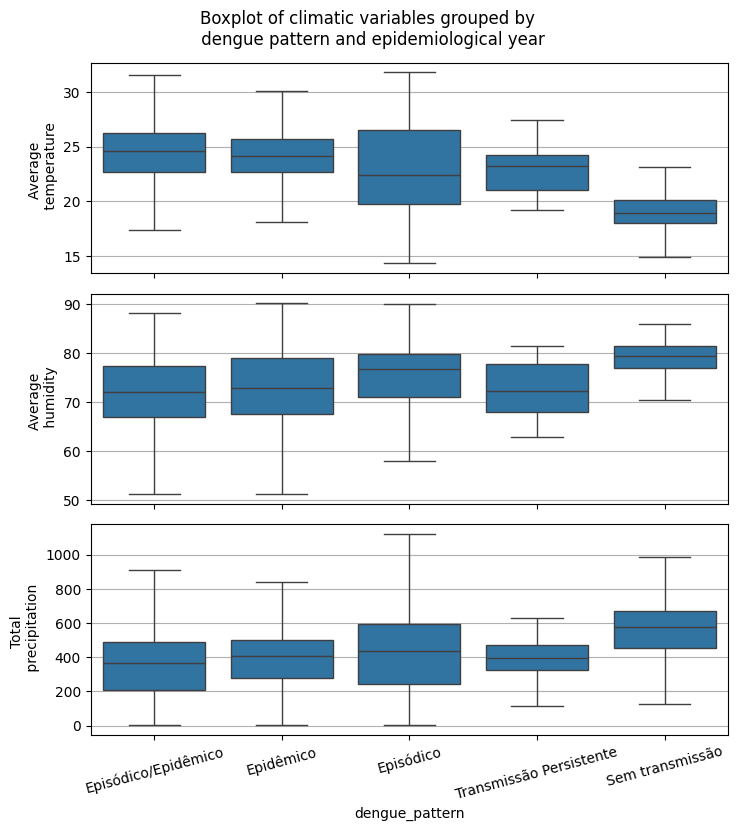

In [5]:
fig, ax = plt.subplots(3,1, figsize = (7.5, 8),  sharex = True)

sns.boxplot(x='dengue_pattern', y='temp_med', data=df, showfliers = False, ax=ax[0])

ax[0].set_ylabel('Average \n temperature')

ax[0].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='umid_med', data=df, showfliers = False, ax=ax[1])

ax[1].set_ylabel('Average \n humidity')

ax[1].grid(True, axis='y')


sns.boxplot(x='dengue_pattern', y='precip_tot', data=df, showfliers = False, ax=ax[2])

ax[2].set_ylabel('Total \n precipitation')

ax[2].grid(True, axis='y')


plt.suptitle('Boxplot of climatic variables grouped by \n dengue pattern and epidemiological year')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('./figures/boxplot_clima.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

Boxplot da população: 

In [8]:
df_perfis = pd.read_csv('./Dengue/dengue_pattern_10_19.csv', sep = ';', usecols = ['muni_code', 'dengue_pattern'])

df_perfis.head()

,muni_code,dengue_pattern
0,1100015,Episódico/Epidêmico
1,1100023,Epidêmico
2,1100031,Episódico/Epidêmico
3,1100049,Epidêmico
4,1100056,Episódico/Epidêmico


In [15]:
df_det = pd.read_csv('Determinantes/banco_determinantes.csv', sep = ';')

df_det = df_det.merge(df_perfis, left_on='muni_code', right_on = 'muni_code')

df_det['altitude'] = df_det['altitude'].str.replace(',', '.').astype(float)

df_det.head()

,muni_code,muni_name,uf_code,uf_acr,tipo_regiao,bioma,altitude,koppen,pop22,dengue_pattern
0,1100015,Alta Floresta D'oeste,11,RO,interior,amazonia,246.08,Am,21558,Episódico/Epidêmico
1,1100023,Ariquemes,11,RO,interior,amazonia,165.90,Am,100896,Epidêmico
2,1100031,Cabixi,11,RO,interior,amazonia,224.18,Am,5107,Episódico/Epidêmico
3,1100049,Cacoal,11,RO,metropolitana,amazonia,229.95,Am,92202,Epidêmico
4,1100056,Cerejeiras,11,RO,interior,amazonia,192.22,Am,15237,Episódico/Epidêmico


In [13]:
df_det.dtypes

muni_code          int64
muni_name         object
uf_code            int64
uf_acr            object
tipo_regiao       object
bioma             object
altitude          object
koppen            object
pop22              int64
dengue_pattern    object
dtype: object

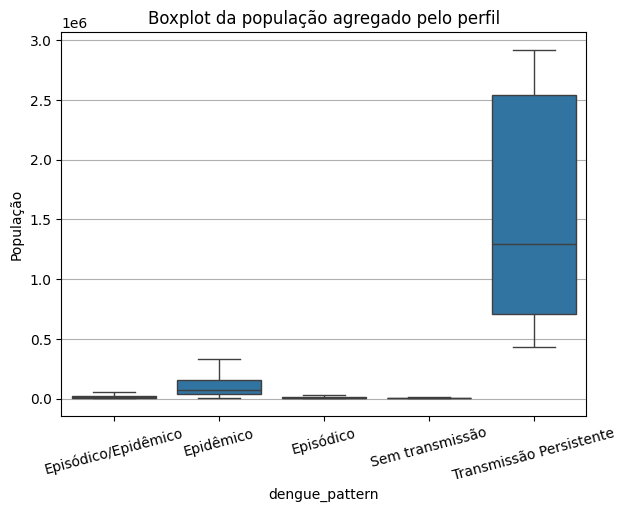

In [10]:
fig, ax = plt.subplots()

sns.boxplot(x='dengue_pattern', y='pop22', data=df_det, showfliers = False, ax=ax)

ax.set_ylabel('População')

ax.grid(True, axis='y')

ax.set_title('Boxplot da população agregado pelo perfil')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('./figures/boxplot_pop.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

Boxplot da altitude: 

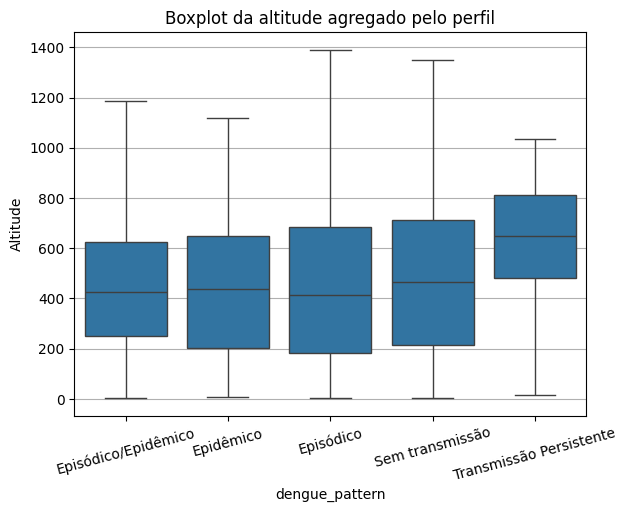

In [16]:
fig, ax = plt.subplots()

sns.boxplot(x='dengue_pattern', y='altitude', data=df_det, showfliers = False, ax=ax)

ax.set_ylabel('Altitude')

ax.grid(True, axis='y')

ax.set_title('Boxplot da altitude agregado pelo perfil')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('./figures/boxplot_alt.png',  dpi = 300, bbox_inches = 'tight')
plt.show()